In [1]:
# =============================================================================
#
# Pronostico time trend + dummy seasonal
#
# =============================================================================

#
# Carga de datos
#
import nbimporter  #  type: ignore
import functions  #  type: ignore


df_orig = functions.load_data()
df_orig.head()






,yt_true
date,
1946-01-01,890
1946-02-01,992
1946-03-01,979
1946-04-01,959
1946-05-01,1110


In [2]:


#
# Componentes de tendencia lineal
#
df_orig = functions.add_linear_trend_component(df_orig)
df_orig.head()




,yt_true,trend
date,,
1946-01-01,890,0
1946-02-01,992,1
1946-03-01,979,2
1946-04-01,959,3
1946-05-01,1110,4


In [3]:

# Componentes estacionales
#
df_orig = functions.add_month_component(df_orig)
df_orig.head(15)




,yt_true,trend,month
date,,,
1946-01-01,890,0,1
1946-02-01,992,1,2
1946-03-01,979,2,3
1946-04-01,959,3,4
1946-05-01,1110,4,5
1946-06-01,1546,5,6
1946-07-01,1539,6,7
1946-08-01,3401,7,8
1946-09-01,2092,8,9


In [4]:
# Particionamiento de los datos
#
(
    X_complete,
    y_complete,
    X_train,
    y_train,
    X_test,
    y_test,
) = functions.train_test_split(
    df=df_orig,
    x_columns=["trend", "month"],
    y_column="yt_true",
)


In [5]:
#
# Especificación del Modelo
#
from sklearn.pipeline import Pipeline  #  type: ignore
from sklearn.preprocessing import (  #  type: ignore
    PolynomialFeatures,
    OneHotEncoder,
    MinMaxScaler,
)
from sklearn.linear_model import LinearRegression  #  type: ignore
from sklearn.compose import ColumnTransformer  #  type: ignore


def create_pipeline(degree):
    pipeline = Pipeline(
        [
            (
                "preprocessor",
                ColumnTransformer(
                    [
                        (
                            "trend",
                            Pipeline(
                                [
                                    ("poly", PolynomialFeatures(degree=degree)),
                                    ("scaler", MinMaxScaler()),
                                ]
                            ),
                            ["trend"],
                        ),
                        ("seasonal", OneHotEncoder(), ["month"]),
                    ]
                ),
            ),
            ("regressor", LinearRegression()),
        ]
    )

    return pipeline



In [6]:
  
#
# Entrenamiento y pronostico
#
for degree in range(1, 4):
    pipeline = create_pipeline(degree=degree)
    pipeline.fit(X_train, y_train)
    df_orig[f"yt_pred_time_trend_{degree}_dummy"] = pipeline.predict(X_complete)
    

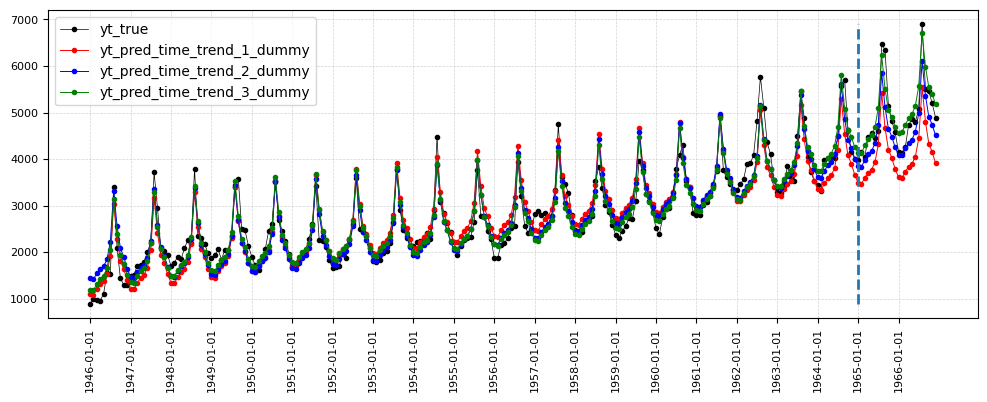

In [7]:

functions.plot_time_series(df_orig)

In [8]:
#
# Almacenamiento de los resultados
#
functions.save_forecasts(df_orig)



In [9]:
#
# Métricas de error
#
metrics = functions.compute_evaluation_metrics(df_orig)
functions.save_metrics(metrics)
metrics


,Metrics,yt_pred_time_trend_1_dummy,yt_pred_time_trend_2_dummy,yt_pred_time_trend_3_dummy
0,MSE Train,103217.67,78075.48,68044.66
1,MSE Test,738282.04,190079.09,107356.45
2,MAE Train,259.03,213.47,202.35
3,MAE Test,804.13,341.66,262.00


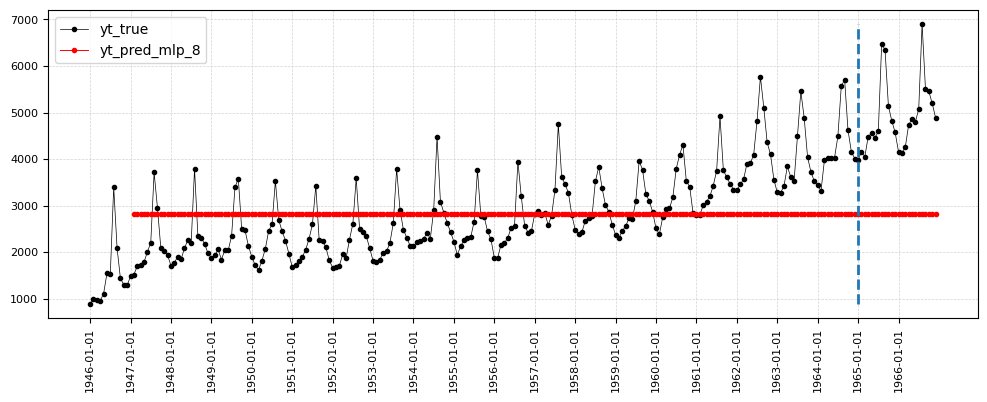

In [10]:
# =============================================================================
#
# Pronositco usando un MLP con la serie sin diferenciar y sin escalar
#
# =============================================================================
import warnings

warnings.filterwarnings("ignore")

#
# Carga de datos
#
import nbimporter  #  type: ignore
import functions  #  type: ignore


df_orig = functions.load_data()
df_orig.head()











#
# Construcción de la matriz de regresores
#

df_orig = functions.make_lagged_ts(
    df=df_orig,
    p_max=13,
    y_column="yt_true",
    fmt="lagged_{}m",
)
df_orig.head()







#
# Remoción de los valores faltantes
#
df_dropna = df_orig.dropna()









#
# División de los datos en entrenamiento y prueba
#
(
    X_complete,
    y_complete,
    X_train,
    y_train,
    X_test,
    y_test,
) = functions.train_test_split(
    df=df_dropna,
    x_columns=[f"lagged_{i}m" for i in range(1, 13)],
    y_column="yt_true",
)







#
# Pronostico usando una red neuronal tipo MLP
#
from sklearn.neural_network import MLPRegressor  #  type: ignore


def create_pipeline(hidden):

    return MLPRegressor(
        hidden_layer_sizes=(hidden,),
        activation="logistic",
        learning_rate="adaptive",
        momentum=0.01,
        learning_rate_init=0.2,
        max_iter=10000,
        random_state=123456,
    )











#
# Entrenamiento y pronostico
#
hidden = 8
pipeline = create_pipeline(hidden=hidden)
pipeline.fit(X_train, y_train)
df_dropna[f"yt_pred_mlp_{hidden}"] = pipeline.predict(X_complete)
df_orig.loc[df_dropna.index, f"yt_pred_mlp_{hidden}"] = df_dropna[
    f"yt_pred_mlp_{hidden}"
]

functions.plot_time_series(df=df_orig, yt_col="yt_true")

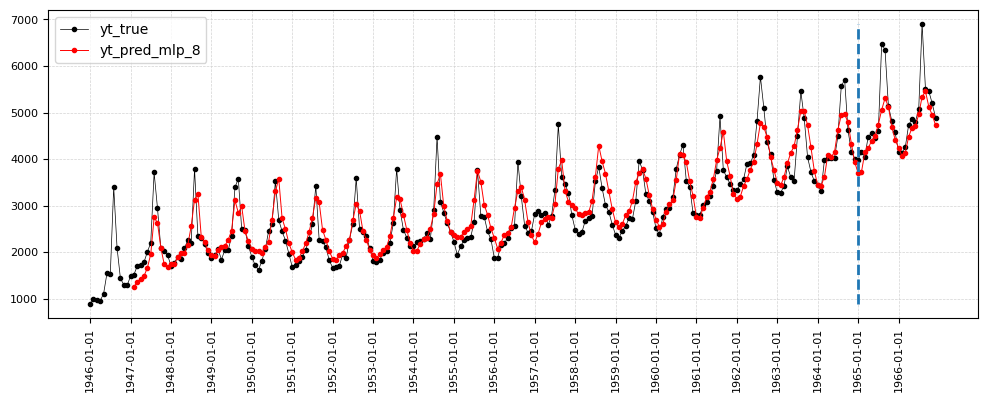

,Metrics,yt_pred_mlp_8
0,MSE Train,109154.28
1,MSE Test,263190.52
2,MAE Train,248.99
3,MAE Test,309.45


In [11]:

# Pronostico usando una red neuronal tipo MLP
#
from sklearn.pipeline import Pipeline  #  type: ignore
from sklearn.preprocessing import MinMaxScaler  #  type: ignore
from sklearn.compose import TransformedTargetRegressor  #  type: ignore
from sklearn.neural_network import MLPRegressor  #  type: ignore


# Crea un pipeline para automatizar la creacion de un modelo
def make_pipeline_from_model(model):
    """Create a pipeline."""
    return Pipeline(
        [
            (
                "scaler",
                MinMaxScaler(),
            ),
            (
                "regressor",
                TransformedTargetRegressor(
                    regressor=model,
                    transformer=MinMaxScaler(),
                ),
            ),
        ]
    )



  
  
#
# Entrenamiento y pronostico
#
hidden = 8
mlp_model = MLPRegressor(
    hidden_layer_sizes=(hidden,),
    activation="logistic",
    learning_rate="adaptive",
    momentum=0.01,
    learning_rate_init=0.2,
    max_iter=10000,
    random_state=123456,
)
mlp_pipeline = make_pipeline_from_model(model=mlp_model)
mlp_pipeline.fit(X_train, y_train)

df_dropna[f"yt_pred_mlp_{hidden}"] = mlp_pipeline.predict(X_complete)
df_dropna[["yt_true", f"yt_pred_mlp_{hidden}"]].head()
  










#
# Gráfica de los pronósticos
#
df_orig.loc[df_dropna.index, f"yt_pred_mlp_{hidden}"] = df_dropna[
    f"yt_pred_mlp_{hidden}"
]

functions.plot_time_series(df=df_orig, yt_col="yt_true")







#
# Almacenamiento de los resultados
#
functions.save_forecasts(df_orig)






#
# Métricas de error
#
metrics = functions.compute_evaluation_metrics(df_orig.dropna())
functions.save_metrics(metrics)
metrics